In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
data_dir = r"C:\Users\igles\Downloads\MOR\banana dataset"

batch_size = 32
img_height = 180
img_width = 180

In [3]:

# 2. LOAD DATA
# ==========================================================
print("Loading Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='binary'
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)




Loading Data...
Found 7814 files belonging to 2 classes.
Using 6252 files for training.
Found 7814 files belonging to 2 classes.
Using 1562 files for validation.


In [4]:
# 3. BUILD MODEL
# ==========================================================

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# Fine-tune settings: Unfreeze the top layers while keeping the bottom layers frozen
base_model.trainable = True
fine_tune_at = 124
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

inputs = keras.Input(shape=(img_height, img_width, 3))

# Removed data_augmentation here - passing inputs directly to preprocess
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

# Regularization layers (Dropout and L2)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid',
                       kernel_regularizer=regularizers.l2(0.01))(x)

model = keras.Model(inputs, outputs)



In [5]:
# 4. COMPILE
# ==========================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# 5. TRAIN
# ==========================================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

epochs = 5
print(f"\nStarting Training...")

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stop, reduce_lr]
)


Starting Training...
Epoch 1/5
196/196 [==============================] - 58s 81ms/step - loss: 0.5849 - accuracy: 0.7113 - val_loss: 0.4193 - val_accuracy: 0.8233 - lr: 1.0000e-05
Epoch 2/5
196/196 [==============================] - 4s 23ms/step - loss: 0.3955 - accuracy: 0.8253 - val_loss: 0.3378 - val_accuracy: 0.8675 - lr: 1.0000e-05
Epoch 3/5
196/196 [==============================] - 4s 22ms/step - loss: 0.3248 - accuracy: 0.8690 - val_loss: 0.3100 - val_accuracy: 0.8732 - lr: 1.0000e-05
Epoch 4/5
196/196 [==============================] - 4s 22ms/step - loss: 0.2805 - accuracy: 0.8860 - val_loss: 0.2621 - val_accuracy: 0.8937 - lr: 1.0000e-05
Epoch 5/5
196/196 [==============================] - 4s 22ms/step - loss: 0.2425 - accuracy: 0.9066 - val_loss: 0.2658 - val_accuracy: 0.8918 - lr: 1.0000e-05



Final Evaluation:
49/49 [==============================] - 1s 19ms/step - loss: 0.2658 - accuracy: 0.8918
Final Validation Accuracy: 89.18%


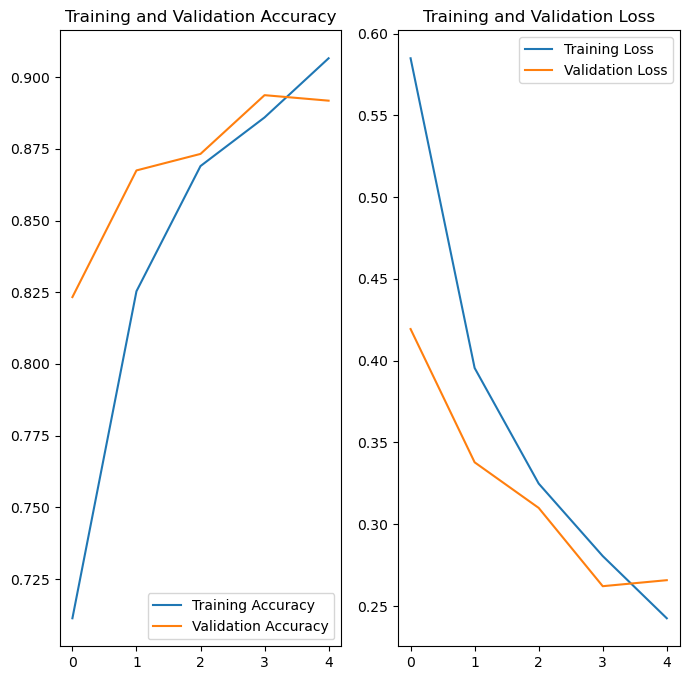

In [6]:
# 6. EVALUATE
# ==========================================================
print("\nFinal Evaluation:")
loss, accuracy = model.evaluate(val_ds)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

# Plotting
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss_vals = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss_vals, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [26]:
def check_image(image_path):

    img_height = 180
    img_width = 180

    # Load image
    img = tf.keras.utils.load_img(image_path)
    img = tf.keras.utils.img_to_array(img)

    # Resize
    img = tf.image.resize(img, [img_height, img_width])

    # Prepare for model
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, 0)   # IMPORTANT

    # Predict
    prediction = model.predict(img)
    score = prediction[0][0]

    if score < 0.5:
        print("Prediction: With Carbide")
    else:
        print("Prediction: Without Carbide")

In [25]:
# Run this to test
test_image_path = r'C:\Users\igles\Downloads\MOR\banana dataset\Without Carbide\556.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 19ms/step
Prediction: Without Carbide {prediction}


In [23]:
# Run this to test
test_image_path = r'C:\Users\igles\Downloads\MOR\banana dataset\With Carbide\556.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 21ms/step
Prediction: With Carbide


In [29]:
# Run this to test
test_image_path = r'C:\Users\igles\MORTEAM13\test4.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 16ms/step
Prediction: Without Carbide


In [28]:
# Run this to test
test_image_path = r"C:\Users\igles\Downloads\1234.jpg"
check_image(test_image_path)

1/1 [==============================] - 0s 16ms/step
Prediction: With Carbide
